Jurnal Referensi Utama : I. Kowsar, S.B Rabbani, M.D Samad
“Attention-Based Imputation of Missing Values in Electronic Health Records Tabular Data,”
in  Proc (IEEE Int Conf Healthc Inform). 2024 June ; 2024: 177–182. doi:10.1109/ichi61247.2024.00030.

Link PDF Jurnal : https://pmc.ncbi.nlm.nih.gov/articles/PMC11463999/pdf/nihms-2010820.pdf



Kelompok 2 Missing Value
```
Muhammad Zahran Albara,122140240
Revolusi A-Ghifari,123140199
Casey Z.D Manurung ,122140054
Royfran Roger Valentino,122140239
Pricelia Putri,122140075
Hayyatul Fajri,122140103
```


In [1]:
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [ ]:
# load built-in dataset (UCI Breast Cancer) — cocok sebagai data tabular klinis kecil
df = pd.read_csv("Gelombang (1).csv", sep=';')  # hanya fitur
df.head()

,Time(UTC/GMT),Hsig(m),Hsig(Scale),Hmax(m),Hmax(Scale),WaveDir(deg),WaveDir(compass),PrimSwell(m),PrimSwell(Scale),PrimSwellDir(deg),...,WindSeaDir(compass),WavePeriod(s),SurfCurrentSpd(cm/s),SurfCurrentDir,SurfCurrentDir(compass),SeaSurfaceTemperature(°C),SeaSurfaceSalinity(PSU),WindSpeed(knots),WindDir(deg),WindDir(compass)
0,2024-07-29 00:00:00,"0,08409",Smooth,"0,16817",Smooth,334,NNW,"0,07923",Smooth,270,...,S,2,"18,54252",187,S,"29,7305","31,0715","1,30439",62,ENE
1,2024-07-29 01:00:00,"0,08298",Smooth,"0,16596",Smooth,334,NNW,"0,07827",Smooth,270,...,S,2,"18,31069",187,S,"29,73114583","31,07397917","1,28032",61,ENE
2,2024-07-29 02:00:00,"0,08188",Smooth,"0,16375",Smooth,334,NNW,"0,0773",Smooth,270,...,S,2,"18,07886",187,S,"29,73179167","31,07645833","1,25624",60,ENE
3,2024-07-29 03:00:00,"0,08077",Smooth,"0,16154",Smooth,334,NNW,"0,07634",Smooth,270,...,S,2,"17,84703",188,S,"29,7324375","31,0789375","1,23217",59,ENE
4,2024-07-29 04:00:00,"0,07966",Smooth,"0,15933",Smooth,334,NNW,"0,07538",Smooth,270,...,S,2,"17,6152",188,S,"29,73308333","31,08141667","1,20809",58,ENE


In [ ]:
scaler = StandardScaler()

#Memilih fitur numerik pada dataset
num_features = df.select_dtypes(include=[np.number]).columns
df[num_features] = scaler.fit_transform(df[num_features])
df.head()

,Time(UTC/GMT),Hsig(m),Hsig(Scale),Hmax(m),Hmax(Scale),WaveDir(deg),WaveDir(compass),PrimSwell(m),PrimSwell(Scale),PrimSwellDir(deg),...,WindSeaDir(compass),WavePeriod(s),SurfCurrentSpd(cm/s),SurfCurrentDir,SurfCurrentDir(compass),SeaSurfaceTemperature(°C),SeaSurfaceSalinity(PSU),WindSpeed(knots),WindDir(deg),WindDir(compass)
0,2024-07-29 00:00:00,"0,08409",Smooth,"0,16817",Smooth,1.575951,NNW,"0,07923",Smooth,0.632261,...,S,-0.661029,"18,54252",1.116785,S,"29,7305","31,0715","1,30439",-1.903146,ENE
1,2024-07-29 01:00:00,"0,08298",Smooth,"0,16596",Smooth,1.575951,NNW,"0,07827",Smooth,0.632261,...,S,-0.661029,"18,31069",1.116785,S,"29,73114583","31,07397917","1,28032",-1.917039,ENE
2,2024-07-29 02:00:00,"0,08188",Smooth,"0,16375",Smooth,1.575951,NNW,"0,0773",Smooth,0.632261,...,S,-0.661029,"18,07886",1.116785,S,"29,73179167","31,07645833","1,25624",-1.930932,ENE
3,2024-07-29 03:00:00,"0,08077",Smooth,"0,16154",Smooth,1.575951,NNW,"0,07634",Smooth,0.632261,...,S,-0.661029,"17,84703",1.132524,S,"29,7324375","31,0789375","1,23217",-1.944825,ENE
4,2024-07-29 04:00:00,"0,07966",Smooth,"0,15933",Smooth,1.575951,NNW,"0,07538",Smooth,0.632261,...,S,-0.661029,"17,6152",1.132524,S,"29,73308333","31,08141667","1,20809",-1.958717,ENE


In [ ]:
#Memilih fitur kategorikal pada dataset
label_encoder = LabelEncoder()
categorical_features = df.select_dtypes(include=['object'])
encoders = {} # Initialize an empty dictionary to store encoders

for feature in categorical_features:
  # Fit and store the encoder for each categorical feature
  encoders[feature] = LabelEncoder()
  df[feature] = encoders[feature].fit_transform(df[feature])


df.head()

,Time(UTC/GMT),Hsig(m),Hsig(Scale),Hmax(m),Hmax(Scale),WaveDir(deg),WaveDir(compass),PrimSwell(m),PrimSwell(Scale),PrimSwellDir(deg),...,WindSeaDir(compass),WavePeriod(s),SurfCurrentSpd(cm/s),SurfCurrentDir,SurfCurrentDir(compass),SeaSurfaceTemperature(°C),SeaSurfaceSalinity(PSU),WindSpeed(knots),WindDir(deg),WindDir(compass)
0,0,2462,1,2731,1,1.575951,0,3314,0,0.632261,...,0,-0.661029,1277,1.116785,8,509,1279,1151,-1.903146,1
1,1,2448,1,2714,1,1.575951,0,3300,0,0.632261,...,0,-0.661029,1236,1.116785,8,511,1303,1115,-1.917039,1
2,2,2429,1,2697,1,1.575951,0,3290,0,0.632261,...,0,-0.661029,1207,1.116785,8,513,1315,1064,-1.930932,1
3,3,2408,1,2679,1,1.575951,0,3274,0,0.632261,...,0,-0.661029,1184,1.132524,8,514,1324,1020,-1.944825,1
4,4,2391,1,2661,1,1.575951,0,3264,0,0.632261,...,0,-0.661029,1162,1.132524,8,517,1334,980,-1.958717,1


In [ ]:
df.isnull().sum()

,0
Time(UTC/GMT),0
Hsig(m),0
Hsig(Scale),0
Hmax(m),0
Hmax(Scale),0
WaveDir(deg),0
WaveDir(compass),0
PrimSwell(m),0
PrimSwell(Scale),0
PrimSwellDir(deg),0


In [ ]:
# simulasikan missingness acak — kita akan menebak nilai di posisi ini
rng = np.random.RandomState(42)
missing_fraction = 0.20   # 20% missing per sel (atur sesuai kebutuhan)

df_full = df.copy()   # simpan ground truth
mask_matrix = rng.rand(*df.shape) >= missing_fraction  # True = observed, False = missing
df_observed = df_full.mask(~mask_matrix)               # set missing as NaN

print("Original shape:", df_full.shape)
print("Count missing per column:")
print(df_observed.isna().sum())


Original shape: (8737, 24)
Count missing per column:
Time(UTC/GMT)                1723
Hsig(m)                      1800
Hsig(Scale)                  1724
Hmax(m)                      1728
Hmax(Scale)                  1749
WaveDir(deg)                 1714
WaveDir(compass)             1735
PrimSwell(m)                 1750
PrimSwell(Scale)             1726
PrimSwellDir(deg)            1766
PrimSwellDir(compass)        1808
WindSea(m)                   1750
WindSea(Scale)               1749
WindSeaDir(deg)              1723
WindSeaDir(compass)          1771
WavePeriod(s)                1751
SurfCurrentSpd(cm/s)         1695
SurfCurrentDir               1806
SurfCurrentDir(compass)      1748
SeaSurfaceTemperature(°C)    1756
SeaSurfaceSalinity(PSU)      1817
WindSpeed(knots)             1725
WindDir(deg)                 1684
WindDir(compass)             1747
dtype: int64


In [ ]:
df_observed.isnull().sum()

,0
Time(UTC/GMT),1723
Hsig(m),1800
Hsig(Scale),1724
Hmax(m),1728
Hmax(Scale),1749
WaveDir(deg),1714
WaveDir(compass),1735
PrimSwell(m),1750
PrimSwell(Scale),1726
PrimSwellDir(deg),1766


In [ ]:
# Standardize numeric features (fit on full data to keep ground truth scale for evaluation)

# --- Start of fix: Preprocessing df_full and df_observed to handle non-numeric data ---

# 1. Convert columns with comma decimals to float in both df_full and df_observed
comma_numeric_cols = [
    'Hsig(m)', 'Hmax(m)', 'PrimSwell(m)', 'WindSea(m)', 'SurfCurrentSpd(cm/s)',
    'SeaSurfaceTemperature(°C)', 'SeaSurfaceSalinity(PSU)', 'WindSpeed(knots)'
]
for col in comma_numeric_cols:
    if col in df_full.columns:
        if df_full[col].dtype == 'object':
            df_full.loc[:, col] = df_full[col].astype(str).str.replace(',', '.', regex=False).astype(float)
        if df_observed[col].dtype == 'object':
            # For df_observed, ensure NaNs are handled gracefully: convert to string, replace comma, handle empty strings, then convert to float
            # Removed `na=''` from str.replace as it's not a valid argument for that method.
            df_observed.loc[:, col] = df_observed[col].astype(str).str.replace(',', '.', regex=False).replace('', np.nan).astype(float)

# 2. Convert 'Time(UTC/GMT)' to numerical (Unix timestamp) in both df_full and df_observed
if 'Time(UTC/GMT)' in df_full.columns:
    # For df_full: Convert to datetime, then to Unix timestamp (float) in seconds
    df_full.loc[:, 'Time(UTC/GMT)'] = pd.to_datetime(df_full['Time(UTC/GMT)'], errors='coerce')
    df_full.loc[:, 'Time(UTC/GMT)'] = df_full['Time(UTC/GMT)'].apply(lambda x: x.timestamp() if pd.notna(x) else np.nan)

    # For df_observed: Handle NaNs in datetime conversion and convert to Unix timestamp (float) in seconds
    observed_time_ts = pd.Series(np.nan, index=df_observed.index)
    valid_time_mask = df_observed['Time(UTC/GMT)'].notna()
    valid_datetimes = pd.to_datetime(df_observed.loc[valid_time_mask, 'Time(UTC/GMT)'], errors='coerce')
    observed_time_ts[valid_time_mask] = valid_datetimes.apply(lambda x: x.timestamp() if pd.notna(x) else np.nan)
    df_observed.loc[:, 'Time(UTC/GMT)'] = observed_time_ts

# 3. Identify and drop remaining non-numerical (categorical string) columns from both df_full and df_observed
# These are columns like 'Hsig(Scale)', 'WaveDir(compass)', etc.
cols_to_drop = [col for col in df_full.columns if df_full[col].dtype == 'object']

if cols_to_drop:
    print(f"Dropping non-numeric categorical columns for numerical imputation: {cols_to_drop}")
    df_full = df_full.drop(columns=cols_to_drop)
    df_observed = df_observed.drop(columns=cols_to_drop)

# --- End of fix: df_full and df_observed should now be entirely numerical ---

scaler = StandardScaler()
# Ensure all values are numeric, NaNs are handled by fillna(0) for X_obs
X_full = scaler.fit_transform(df_full.values.astype(float))   # ground truth scaled
X_obs = scaler.transform(df_observed.fillna(0).values.astype(float))  # fill NaN->0 for input

# Masks: observed = 1, missing = 0
mask = (~np.isnan(df_observed.values)).astype(float)

# Convert to torch tensors
X_full_t = torch.tensor(X_full, dtype=torch.float32)   # target
X_obs_t  = torch.tensor(X_obs, dtype=torch.float32)    # input with placeholder 0
mask_t   = torch.tensor(mask, dtype=torch.float32)     # indicator: 1 observed, 0 missing

print("Tensors shapes:", X_full_t.shape, X_obs_t.shape, mask_t.shape)

/tmp/ipython-input-161826204.py:22: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '<DatetimeArray>
[          '1970-01-01 00:00:00', '1970-01-01 00:00:00.000000001',
 '1970-01-01 00:00:00.000000002', '1970-01-01 00:00:00.000000003',
 '1970-01-01 00:00:00.000000004', '1970-01-01 00:00:00.000000005',
 '1970-01-01 00:00:00.000000006', '1970-01-01 00:00:00.000000007',
 '1970-01-01 00:00:00.000000008', '1970-01-01 00:00:00.000000009',
 ...
 '1970-01-01 00:00:00.000008727', '1970-01-01 00:00:00.000008728',
 '1970-01-01 00:00:00.000008729', '1970-01-01 00:00:00.000008730',
 '1970-01-01 00:00:00.000008731', '1970-01-01 00:00:00.000008732',
 '1970-01-01 00:00:00.000008733', '1970-01-01 00:00:00.000008734',
 '1970-01-01 00:00:00.000008735', '1970-01-01 00:00:00.000008736']
Length: 8737, dtype: datetime64[ns]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_full.loc[:, 'Time(UTC/GMT)

Tensors shapes: torch.Size([8737, 24]) torch.Size([8737, 24]) torch.Size([8737, 24])


In [ ]:
df.head()

,Time(UTC/GMT),Hsig(m),Hsig(Scale),Hmax(m),Hmax(Scale),WaveDir(deg),WaveDir(compass),PrimSwell(m),PrimSwell(Scale),PrimSwellDir(deg),...,WindSeaDir(compass),WavePeriod(s),SurfCurrentSpd(cm/s),SurfCurrentDir,SurfCurrentDir(compass),SeaSurfaceTemperature(°C),SeaSurfaceSalinity(PSU),WindSpeed(knots),WindDir(deg),WindDir(compass)
0,0,2462,1,2731,1,1.575951,0,3314,0,0.632261,...,0,-0.661029,1277,1.116785,8,509,1279,1151,-1.903146,1
1,1,2448,1,2714,1,1.575951,0,3300,0,0.632261,...,0,-0.661029,1236,1.116785,8,511,1303,1115,-1.917039,1
2,2,2429,1,2697,1,1.575951,0,3290,0,0.632261,...,0,-0.661029,1207,1.116785,8,513,1315,1064,-1.930932,1
3,3,2408,1,2679,1,1.575951,0,3274,0,0.632261,...,0,-0.661029,1184,1.132524,8,514,1324,1020,-1.944825,1
4,4,2391,1,2661,1,1.575951,0,3264,0,0.632261,...,0,-0.661029,1162,1.132524,8,517,1334,980,-1.958717,1


In [ ]:
from torch.utils.data import TensorDataset, DataLoader

batch_size = 32
dataset = TensorDataset(X_obs_t, mask_t, X_full_t)
train_set, val_set = torch.utils.data.random_split(dataset, [int(len(dataset)*0.8), len(dataset)-int(len(dataset)*0.8)])
train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_set, batch_size=batch_size, shuffle=False)


In [ ]:
class TabTransformerImputer(nn.Module):
    def __init__(self, num_features, d_model=64, nhead=4, num_layers=2, dropout=0.1):
        super().__init__()
        self.num_features = num_features
        self.d_model = d_model

        # scalar value -> embedding
        self.value_emb = nn.Linear(1, d_model)
        # mask indicator embedding (observed/missing)
        self.mask_emb = nn.Linear(1, d_model)
        # learned positional/feature id embedding (feature identity)
        self.feature_emb = nn.Embedding(num_features, d_model)

        encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward=d_model*4, dropout=dropout)
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # regressor per feature (map back to scalar)
        self.out_layer = nn.Linear(d_model, 1)

    def forward(self, x, mask):
        # x: (batch, num_features)  scaled numeric values (placeholder zeros where missing)
        # mask: (batch, num_features)  1 observed, 0 missing

        b, f = x.size()
        # reshape scalars -> (batch, features, 1)
        x_val = x.unsqueeze(-1)             # (b, f, 1)
        mask_in = mask.unsqueeze(-1)        # (b, f, 1)

        # embeddings
        val_emb = self.value_emb(x_val)     # (b, f, d_model)
        mask_emb = self.mask_emb(mask_in)   # (b, f, d_model)

        # feature id embedding
        ids = torch.arange(f, device=x.device).unsqueeze(0).repeat(b,1)   # (b, f)
        feat_emb = self.feature_emb(ids)   # (b, f, d_model)

        tokens = val_emb + mask_emb + feat_emb  # (b, f, d_model)

        # transformer expects (seq_len, batch, d_model)
        tokens = tokens.permute(1,0,2)  # (f, b, d_model)
        out = self.transformer(tokens)  # (f, b, d_model)
        out = out.permute(1,0,2)        # (b, f, d_model)

        preds = self.out_layer(out).squeeze(-1)  # (b, f)

        # final imputed values: keep observed values, replace missing with preds
        imputed = mask * x + (1 - mask) * preds
        return imputed, preds

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_features = X_obs_t.shape[1]

model = TabTransformerImputer(num_features=num_features, d_model=64, nhead=4, num_layers=2).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

# loss computed only on positions that are missing (we train to predict missing entries)
mse_loss = nn.MSELoss(reduction='sum')  # sum -> we'll normalize by count

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  warnings.warn(


In [ ]:
def evaluate(loader):
    model.eval()
    total_loss = 0.0
    total_count = 0
    with torch.no_grad():
        for xb, maskb, yb in loader:
            xb = xb.to(device); maskb = maskb.to(device); yb = yb.to(device)
            imputed, preds = model(xb, maskb)
            # compute loss only at missing positions (mask == 0)
            miss_positions = (maskb == 0).float()
            count = miss_positions.sum().item()
            if count == 0:
                continue
            loss = mse_loss(preds * miss_positions, yb * miss_positions)
            total_loss += loss.item()
            total_count += count
    return (total_loss / total_count) if total_count>0 else 0.0

epochs = 60
for epoch in range(1, epochs+1):
    model.train()
    train_loss = 0.0
    train_count = 0
    for xb, maskb, yb in train_loader:
        xb = xb.to(device); maskb = maskb.to(device); yb = yb.to(device)
        optimizer.zero_grad()
        imputed, preds = model(xb, maskb)
        miss_positions = (maskb == 0).float()
        count = miss_positions.sum().item()
        if count == 0:
            continue
        loss = mse_loss(preds * miss_positions, yb * miss_positions) / (count)  # mean over missing
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * count
        train_count += count
    val_loss = evaluate(val_loader)
    avg_train = (train_loss / train_count) if train_count>0 else 0.0
    if epoch % 5 == 0 or epoch == 1:
        print(f"Epoch {epoch:03d} | train_loss_missing={avg_train:.6f} | val_loss_missing={val_loss:.6f}")

Epoch 001 | train_loss_missing=0.845006 | val_loss_missing=0.531843
Epoch 005 | train_loss_missing=0.263508 | val_loss_missing=0.213619
Epoch 010 | train_loss_missing=0.211745 | val_loss_missing=0.220203
Epoch 015 | train_loss_missing=0.189056 | val_loss_missing=0.166437
Epoch 020 | train_loss_missing=0.180339 | val_loss_missing=0.171816
Epoch 025 | train_loss_missing=0.170543 | val_loss_missing=0.173357
Epoch 030 | train_loss_missing=0.179376 | val_loss_missing=0.171271
Epoch 035 | train_loss_missing=0.157068 | val_loss_missing=0.157642
Epoch 040 | train_loss_missing=0.141630 | val_loss_missing=0.136236
Epoch 045 | train_loss_missing=0.142304 | val_loss_missing=0.133834
Epoch 050 | train_loss_missing=0.142786 | val_loss_missing=0.142705
Epoch 055 | train_loss_missing=0.134665 | val_loss_missing=0.132513
Epoch 060 | train_loss_missing=0.144233 | val_loss_missing=0.144888


In [ ]:
model.eval()
with torch.no_grad():
    X_obs_cuda = X_obs_t.to(device)
    mask_cuda = mask_t.to(device)
    imputed_scaled, _ = model(X_obs_cuda, mask_cuda)
    imputed_scaled = imputed_scaled.cpu().numpy()

# inverse scale to original
imputed_original = scaler.inverse_transform(imputed_scaled)

df_imputed = pd.DataFrame(imputed_original, columns=df.columns)
# Also create a dataframe showing where we had missing and what model predicted vs ground truth
sample_idx = 0
print("Row", sample_idx)
print("Original (ground-truth):")
print(pd.Series(X_full[sample_idx], index=df.columns).head())
print("Observed input (NaN where missing):")
print(df_observed.iloc[sample_idx].head())
print("Imputed result (model):")
print(df_imputed.iloc[sample_idx].head())


Row 0
Original (ground-truth):
Time(UTC/GMT)   -1.712171
Hsig(m)         -0.458333
Hsig(Scale)      0.066093
Hmax(m)         -0.471560
Hmax(Scale)      0.504217
dtype: float64
Observed input (NaN where missing):
Time(UTC/GMT)       0.0
Hsig(m)          2462.0
Hsig(Scale)         1.0
Hmax(m)          2731.0
Hmax(Scale)         NaN
Name: 0, dtype: float64
Imputed result (model):
Time(UTC/GMT)    1.549413e-14
Hsig(m)          2.462000e+03
Hsig(Scale)      1.000000e+00
Hmax(m)          2.731000e+03
Hmax(Scale)      9.978171e-01
Name: 0, dtype: float32


In [ ]:
# compute RMSE only on positions that were masked (artificial missing)
mask_missing = (mask == 0).astype(bool)
gt = X_full
pred = imputed_scaled

mse = ((gt[mask_missing] - pred[mask_missing])**2).mean()
rmse = np.sqrt(mse)
print(f"RMSE on artificially missing values (scaled space): {rmse:.6f}")

# if want in original units, compute using inverse scaled arrays
gt_orig = scaler.inverse_transform(gt)
pred_orig = imputed_original
mse_orig = ((gt_orig[mask_missing] - pred_orig[mask_missing])**2).mean()
rmse_orig = np.sqrt(mse_orig)
print(f"RMSE on artificially missing values (original units): {rmse_orig:.6f}")


RMSE on artificially missing values (scaled space): 0.335571
RMSE on artificially missing values (original units): 311.733896


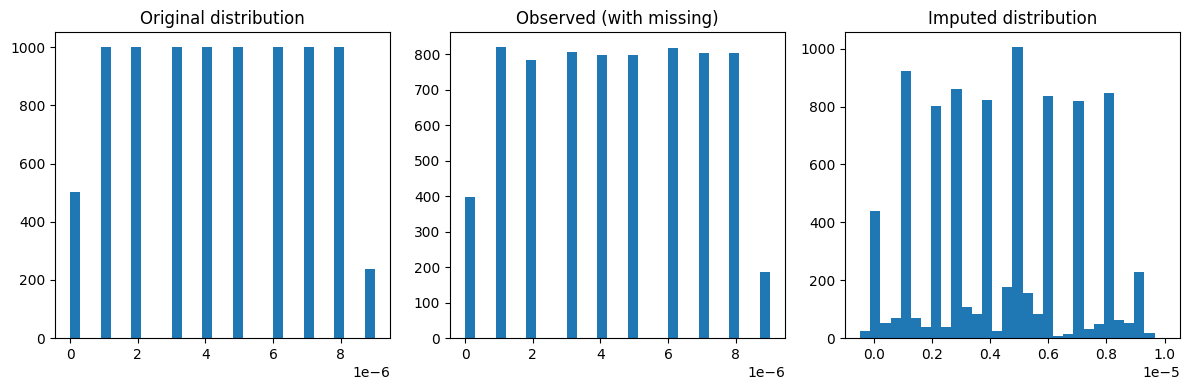

In [ ]:
col = df.columns[0]  # pick first feature
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
plt.hist(df_full[col].dropna(), bins=30)
plt.title("Original distribution")

plt.subplot(1,3,2)
plt.hist(df_observed[col].dropna(), bins=30)
plt.title("Observed (with missing)")

plt.subplot(1,3,3)
plt.hist(df_imputed[col].dropna(), bins=30)
plt.title("Imputed distribution")
plt.tight_layoutcol = df.columns[0]  # pick first feature

plt.tight_layout()

In [ ]:
torch.save({
    'model_state_dict': model.state_dict(),
    'scaler': scaler,
}, "transformer_imputer_checkpoint.pth")
print("Model saved: transformer_imputer_checkpoint.pth")


Model saved: transformer_imputer_checkpoint.pth
